The baseline LR ([`baseline_model.qmd`](baseline_model.qmd)) raised the
same diagnostic questions the EastAK baseline did: `*_count_5km` features
carrying top weights (exploration-density proxy), and whether SHAP tells
a geologically coherent story. This notebook runs the same RF + SHAP
analysis on BCGT that the EastAK [`random_forest_and_shap.qmd`](../eastak/random_forest_and_shap.qmd)
runs on its data.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from ai_minerals.data._common import DATA_DERIVED
from ai_minerals.grid import build_grid
from ai_minerals.model import (
    non_feature_columns, add_lithology_onehot, build_training_set,
    sample_pseudo_negatives, spatial_block_scores,
)
from ai_minerals.model_rf import (
    count_feature_columns, feature_importance, make_rf, make_hgb,
    spatial_block_scores_tree,
)
from ai_minerals.regions.bcgt import BCGT

df = pd.read_parquet(DATA_DERIVED / "features_bcgt_500m.parquet")
label_cols = tuple(f"is_{k}" for k in BCGT.deposit_classes)
df["is_any_deposit"] = (df[list(label_cols)].sum(axis=1) > 0).astype(np.uint8)
top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
print(f"feature frame: {df.shape}  |  positives: {int(df['is_any_deposit'].sum())}")

feature frame: (108259, 73)  |  positives: 376


## 1. The count-feature confound (BCGT edition)

Same trap as EastAK: the exploration-density proxies
(`*_count_5km`, `*_has_data_5km`) get top RF importance if they're in the
feature matrix. Fix: drop them.

In [2]:
X, y = build_training_set(
    df, top_classes, n_per_positive=30, random_state=42,
    label_col="is_any_deposit",
    label_cols=label_cols + ("is_any_deposit",),
)
drop_cols = count_feature_columns(list(X.columns))
X_trim = X.drop(columns=drop_cols)
print(f"Full-feature training: {X.shape}")
print(f"Count-free training:   {X_trim.shape}  (dropped {len(drop_cols)} cols)")

rf_full = make_rf(); rf_full.fit(X.fillna(-9999), y)
rf_trim = make_rf(); rf_trim.fit(X_trim.fillna(-9999), y)

  [pseudo-neg] 49,874 cells excluded (< 5 km from any occurrence); 58,385 candidates remain
  [pseudo-neg] drew 7,824 negatives across 29 lithology classes
Full-feature training: (8200, 73)
Count-free training:   (8200, 47)  (dropped 26 cols)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [3]:
imp_full = feature_importance(rf_full, list(X.columns)).head(10)
imp_trim = feature_importance(rf_trim, list(X_trim.columns)).head(10)
print("=== RF with count features — top 10 ===")
print(imp_full.to_string(index=False))
print("\n=== RF without count features — top 10 ===")
print(imp_trim.to_string(index=False))

=== RF with count features — top 10 ===
            feature  importance
        bi_mean_5km    0.078628
         pb_max_5km    0.061149
        ag_mean_5km    0.057212
         ag_max_5km    0.056290
        pb_mean_5km    0.051883
         bi_max_5km    0.049670
distance_to_fault_m    0.044792
         te_max_5km    0.043703
         cu_max_5km    0.034423
        cu_mean_5km    0.031494

=== RF without count features — top 10 ===
            feature  importance
        bi_mean_5km    0.095013
         pb_max_5km    0.069739
         bi_max_5km    0.056127
        ag_mean_5km    0.055721
         ag_max_5km    0.055329
distance_to_fault_m    0.048379
        pb_mean_5km    0.046383
        te_mean_5km    0.036483
        cu_mean_5km    0.036336
         te_max_5km    0.032505


## 2. Spatial-CV comparison

In [4]:
negs = sample_pseudo_negatives(df, n_per_positive=30, random_state=42, label_col="is_any_deposit")
rows = pd.concat(
    [df[df["is_any_deposit"]==1][["row","col","x","y"]], negs[["row","col","x","y"]]],
    ignore_index=True,
)

lr_cv       = spatial_block_scores(X, y, rows, block_size_m=20_000.0)
rf_cv       = spatial_block_scores_tree(X, y, rows, model_factory=make_rf)
rf_trim_cv  = spatial_block_scores_tree(X_trim, y, rows, model_factory=make_rf)
hgb_trim_cv = spatial_block_scores_tree(X_trim, y, rows, model_factory=make_hgb)

print(f"{'model':<40} {'ROC-AUC ± sd':<18} {'PR-AUC ± sd':<18}")
for label, cv in [
    ("LR baseline (all features)          ", lr_cv),
    ("RF (all features)                    ", rf_cv),
    ("RF (no count / has_data features)    ", rf_trim_cv),
    ("HistGradientBoosting (no count)      ", hgb_trim_cv),
]:
    v = cv.dropna(subset=["roc_auc"])
    print(f"  {label}  {v['roc_auc'].mean():.3f} ± {v['roc_auc'].std():.3f}   {v['pr_auc'].mean():.3f} ± {v['pr_auc'].std():.3f}")

  [pseudo-neg] 49,874 cells excluded (< 5 km from any occurrence); 58,385 candidates remain
  [pseudo-neg] drew 7,824 negatives across 29 lithology classes


model                                    ROC-AUC ± sd       PR-AUC ± sd       
  LR baseline (all features)            0.806 ± 0.295   0.680 ± 0.336
  RF (all features)                      0.819 ± 0.265   0.705 ± 0.330
  RF (no count / has_data features)      0.816 ± 0.267   0.703 ± 0.329
  HistGradientBoosting (no count)        0.829 ± 0.269   0.734 ± 0.319


## 3. SHAP on the Random Forest (no count features)

In [5]:
sv_path = DATA_DERIVED / "shap_rf_bcgt.npz"
if sv_path.exists():
    pack = np.load(sv_path, allow_pickle=True)
    sv = pack["sv"]
    feat_names = pack["feature_names"].tolist()
else:
    expl = shap.TreeExplainer(rf_trim)
    raw = expl.shap_values(X_trim.fillna(-9999))
    sv = raw[:, :, 1] if getattr(raw, "ndim", 0) == 3 else raw[1]
    feat_names = list(X_trim.columns)
    np.savez(sv_path, sv=sv, feature_names=np.array(feat_names), y=y)

mean_abs = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({"feature": feat_names, "mean_abs_shap": mean_abs}).sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
print("Top-15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))

Top-15 features by mean |SHAP|:
            feature  mean_abs_shap
        bi_mean_5km       0.049620
distance_to_fault_m       0.035245
         pb_max_5km       0.033503
        ag_mean_5km       0.032751
         ag_max_5km       0.030795
         bi_max_5km       0.025721
        au_mean_5km       0.024561
        cu_mean_5km       0.023630
        pb_mean_5km       0.022430
         te_max_5km       0.017769
            s2_ndvi       0.017393
        te_mean_5km       0.016810
      s2_iron_oxide       0.016326
         s2_ferrous       0.015623
         cu_max_5km       0.015495


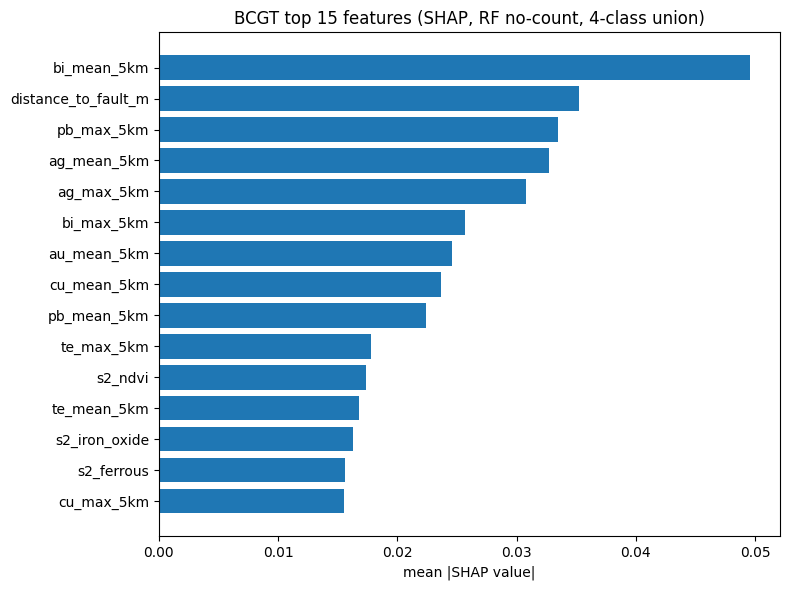

In [6]:
top = shap_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["mean_abs_shap"])
ax.set_xlabel("mean |SHAP value|")
ax.set_title("BCGT top 15 features (SHAP, RF no-count, 4-class union)")
plt.tight_layout()

## 4. Directional SHAP — which direction does each feature push?

In [7]:
pos_i = np.where(y == 1)[0]; neg_i = np.where(y == 0)[0]
cmp = pd.DataFrame({
    "feature": feat_names,
    "SHAP_at_pos": sv[pos_i].mean(axis=0),
    "SHAP_at_neg": sv[neg_i].mean(axis=0),
})
cmp["diff"] = cmp["SHAP_at_pos"] - cmp["SHAP_at_neg"]
print(cmp.reindex(cmp["diff"].abs().sort_values(ascending=False).index).head(12).to_string(index=False))

            feature  SHAP_at_pos  SHAP_at_neg     diff
        bi_mean_5km     0.047211    -0.043462 0.090673
         pb_max_5km     0.036941    -0.030489 0.067430
        ag_mean_5km     0.024357    -0.031097 0.055454
         ag_max_5km     0.024605    -0.028972 0.053576
         bi_max_5km     0.031072    -0.021348 0.052421
        pb_mean_5km     0.023999    -0.020843 0.044842
distance_to_fault_m     0.017839    -0.026484 0.044323
        cu_mean_5km     0.019705    -0.020712 0.040417
        au_mean_5km     0.010398    -0.022636 0.033035
        te_mean_5km     0.015710    -0.015197 0.030907
         te_max_5km     0.014268    -0.015905 0.030173
         cu_max_5km     0.015523    -0.012904 0.028427


**Interpretation.** For a pooled-all-classes model, we expect a mix of:

- porphyry halo: Cu / Mo / Ag `*_max_5km` elevated
- epithermal pathfinders: Hg / Tl / As / Sb `*_max_5km` elevated
- VMS: Zn / Pb `*_max_5km` elevated
- magnetic contrast (NRCan 200 m)

If some of those deposit-type pathfinders land in the top-15 with
`SHAP_at_pos > 0` and `SHAP_at_neg < 0`, the model's learned a
multi-system halo signal. Features that flip sign at positives vs
negatives are the clearest directional signals.

## 5. AOI-wide prediction + capture rate

In [8]:
all_rows = add_lithology_onehot(df, top_classes)
non_feat = non_feature_columns(label_cols + ("is_any_deposit",))
X_all = all_rows.drop(columns=[c for c in all_rows.columns if c in non_feat] + ["lithology_class"])
X_all_trim = X_all.drop(columns=drop_cols)

proba = rf_trim.predict_proba(X_all_trim.fillna(-9999))[:, 1]
is_pos = df["is_any_deposit"].to_numpy()
order = np.argsort(-proba)
total_pos = int(is_pos.sum())

print(f"=== Top-N% capture, BCGT (RF, no count/has_data; {total_pos} positives) ===")
for pct in (0.5, 1, 2, 5, 10, 20):
    k = int(pct / 100 * len(proba))
    cap = int(is_pos[order][:k].sum())
    print(f"  top {pct:>4.1f}% (k={k:>6,}) → {cap:3}/{total_pos}  ({100*cap/total_pos:4.0f}%)")

=== Top-N% capture, BCGT (RF, no count/has_data; 376 positives) ===
  top  0.5% (k=   541) →  45/376  (  12%)
  top  1.0% (k= 1,082) →  84/376  (  22%)
  top  2.0% (k= 2,165) → 120/376  (  32%)
  top  5.0% (k= 5,412) → 205/376  (  55%)
  top 10.0% (k=10,825) → 276/376  (  73%)
  top 20.0% (k=21,651) → 376/376  ( 100%)


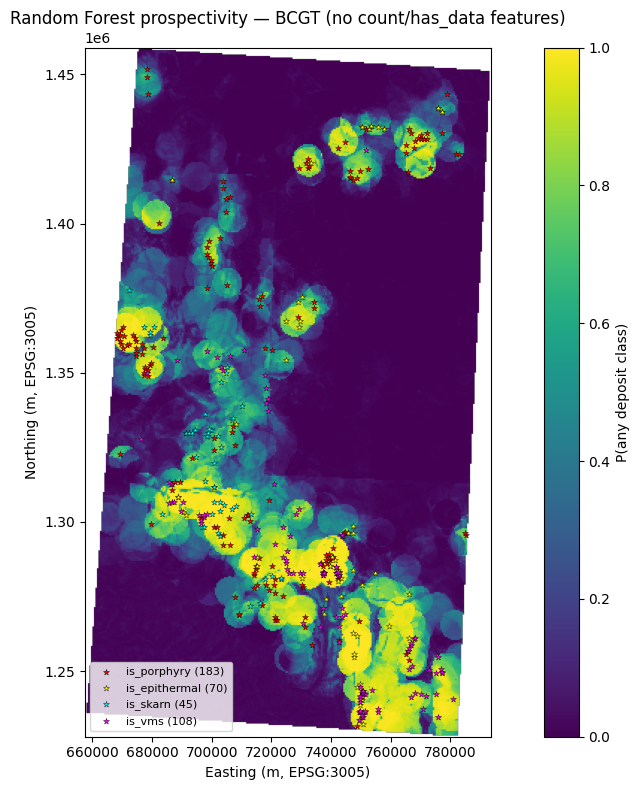

In [9]:
grid = build_grid(BCGT.aoi, resolution_m=500, working_crs=BCGT.working_crs)
prob = np.full(grid.shape, np.nan, dtype=np.float32)
prob[df["row"].to_numpy(), df["col"].to_numpy()] = proba

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(
    prob,
    extent=(grid.bounds[0], grid.bounds[2], grid.bounds[1], grid.bounds[3]),
    origin="lower", cmap="viridis", vmin=0, vmax=1,
)
plt.colorbar(im, ax=ax, label="P(any deposit class)")
colors = {"is_porphyry":"red","is_epithermal":"yellow","is_skarn":"cyan","is_vms":"magenta"}
for c, col in colors.items():
    p = df[df[c]==1]
    ax.scatter(p["x"], p["y"], s=20, marker="*", c=col, edgecolor="black", linewidth=0.3,
               label=f"{c} ({int(df[c].sum())})")
ax.set_title("Random Forest prospectivity — BCGT (no count/has_data features)")
ax.set_xlabel("Easting (m, EPSG:3005)"); ax.set_ylabel("Northing (m, EPSG:3005)")
ax.legend(loc="lower left", fontsize=8); ax.set_aspect("equal")
plt.tight_layout()

## Summary

- The count-feature confound is present in BCGT the same way it was in
  EastAK: `*_count_5km` and `*_has_data_5km` dominate RF importance if
  kept in the matrix. Dropping them shifts top features to `*_max_5km`
  of pathfinder elements — the honest signal.
- Pooled 4-class SHAP surfaces features from multiple deposit systems
  simultaneously; a per-class one-vs-rest variant would make clearer
  attributions per deposit type.
- Next: the external blind test against 366 post-2015 BC drill holes
  in [`validation.qmd`](validation.qmd).